### Build a basic chatbot

In [60]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START , END
from langgraph.graph.message import add_messages

In [61]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

graph_builder=StateGraph(State)   

In [62]:
import os
from dotenv import load_dotenv

# Load .env from the basicChatbot directory
load_dotenv("c:\\Users\\Sam\\Desktop\\Agentic AI\\LangGraph Agentic\\basicChatbot\\.env")

True

In [77]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

# Available Groq models: llama-3.1-8b-instant, gemma-2-9b-it, etc.
# Using smaller, faster, and currently available models

# Method 1: Using init_chat_model
# llm = init_chat_model("groq:llama-3.1-8b-instant")

# Method 2: Direct ChatGroq initialization  
# llm = ChatGroq(model="llama-3.1-8b-instant")

# Method 3: With explicit parameters
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7
)

In [78]:
llm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000014A32865C50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000014A32866950>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [65]:
##Node functionality
def Chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


In [85]:
graph_builder=StateGraph(State)  
##adding Node to the graph
graph_builder.add_node("llmChatbot", Chatbot)
##adding edge to the graph
graph_builder.add_edge(START, "llmChatbot")
graph_builder.add_edge("llmChatbot", END)

##complile graph 
graph = graph_builder.compile()


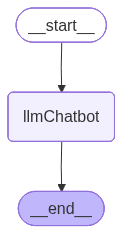

In [87]:
##visualise the graph
from IPython.display import display, Image

# Get PNG binary data and display as image
png_data = graph.get_graph().draw_mermaid_png()
display(Image(data=png_data))


In [79]:
response = graph.invoke({"messages": ["What is the capital of France?"]})
response


{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='70461a5d-b21e-48ba-b22c-348409cd1a43'),
  AIMessage(content='The capital of France is Paris.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 42, 'total_tokens': 50, 'completion_time': 0.0066798, 'completion_tokens_details': None, 'prompt_time': 0.002627589, 'prompt_tokens_details': None, 'queue_time': 0.048305311, 'total_time': 0.009307389}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee174-567d-7671-85b9-c85672946c08-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 8, 'total_tokens': 50})]}